
# 🎓 05 — Final Project: Predicting Student Grades

### A complete, self-contained mini project — start to finish

This notebook brings together everything from `02_NumPy.ipynb`, `03_Pandas.ipynb`, and `04_Matplotlib.ipynb`,
then goes one step further into a real beginner-friendly **machine learning** workflow.

Every import is explained (why we need it), every step explains what it does, and every result explains
what happened and what it means — so you don't need to open any other file or website to follow along.

---

## The Dataset

We're using a real dataset of **2,392 high school students**, including:

- Demographics (age, gender, ethnicity, parental education)
- Study habits (weekly study time, absences, tutoring)
- Support & activities (parental support, extracurriculars, sports, music, volunteering)
- Academic outcome (GPA and GradeClass — a category from 0 = best to 4 = worst)

## The Goal

Can we use a student's habits and background to **predict their GradeClass**?
Along the way we'll also find out **which factors matter most** for academic success.

---

## What this notebook covers

1. Importing libraries (with reasons for each)
2. Loading & exploring the dataset
3. Visualizing feature distributions
4. Separating categorical vs numerical features
5. Encoding & scaling data for machine learning
6. Correlation analysis
7. Splitting data into training and testing sets
8. Finding the most important features
9. Comparing multiple prediction models
10. Evaluating the best model
11. Hyperparameter tuning
12. Reducing to only the most important features
13. Conclusion & key takeaways
14. Mini glossary of machine learning terms used here



---
## 1️⃣ Importing Libraries

We only import what we actually use in this notebook. Here's **why** each one is needed:

| Import | What it's for | Why we need it here |
|---|---|---|
| `numpy` | Fast math & arrays | Needed for numeric operations behind the scenes |
| `pandas` | Tables of data (DataFrames) | To load, explore, and clean the student dataset |
| `matplotlib.pyplot` | Charts & graphs | To visualize distributions and results |
| `seaborn` | Statistical charts (built on Matplotlib) | For a nicer correlation heatmap and confusion matrices |
| `plotly.express` | Interactive charts | For an interactive bar chart comparing model accuracies |
| `sklearn.preprocessing` (`LabelEncoder`, `StandardScaler`) | Prepare data for ML | Machine learning models need **numbers**, not text, and features on a similar scale |
| `sklearn.model_selection` (`train_test_split`, `GridSearchCV`, `RepeatedStratifiedKFold`) | Split data & tune models | To fairly test our model and search for its best settings |
| `sklearn.metrics` (`accuracy_score`, `confusion_matrix`) | Judge how good a model is | To measure and visualize prediction quality |
| Model classes (`LogisticRegression`, `KNeighborsClassifier`, `SVC`, etc.) | The actual prediction **Algorithms** | Each one is a different strategy for learning patterns in data |
| `xgboost`, `lightgbm`, `catboost` | Advanced "boosting" model libraries | These are 3 extra, very powerful models we'll compare against the simpler ones |
| `warnings` | Silences non-critical warning messages | Keeps the notebook's output clean and easy to read |


In [1]:

# Core data tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Tools to prepare data for machine learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold

# Tools to measure how good our predictions are
from sklearn.metrics import accuracy_score, confusion_matrix

# The prediction models (algorithms) we'll compare
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Silence non-critical warning messages so the output stays clean
import warnings
warnings.filterwarnings('ignore')

# A fixed "seed" so random steps (like shuffling data) give the SAME result every time we run this
np.random.seed(42)

print("All libraries loaded successfully! ✅")


All libraries loaded successfully! ✅



---
## 2️⃣ Loading the Dataset

We read the **CSV** file into a Pandas **DataFrame** — this turns the raw text file into a table we can work with in code.


In [2]:

df = pd.read_csv("Student_performance_data__.csv")

print("Dataset loaded! Shape (rows, columns):", df.shape)
df.tail()


Dataset loaded! Shape (rows, columns): (2392, 15)


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0
2391,3392,16,1,0,2,17.819907,13,0,2,0,0,0,1,2.140014,1.0



**What happened:** We now have a table of 2,392 students (rows) and 15 columns (features) each. The `.tail()` shows the last 5 rows, just to confirm the data loaded correctly and looks as expected.



---
## 3️⃣ Exploring the Dataset

Before doing anything else, we check the **Data Type** of every column and whether any values are missing (**NaN**).


In [3]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB



**What happened:** `.info()` lists every column, how many non-missing values it has, and its data type.
Since every column shows **2392 non-null** values (matching our total row count), we know **there is no missing data** to clean up — a lucky and convenient starting point.



---
## 4️⃣ Visualizing Feature Distributions

A **Histogram** for every column at once gives us a fast overview of how each feature is spread out.


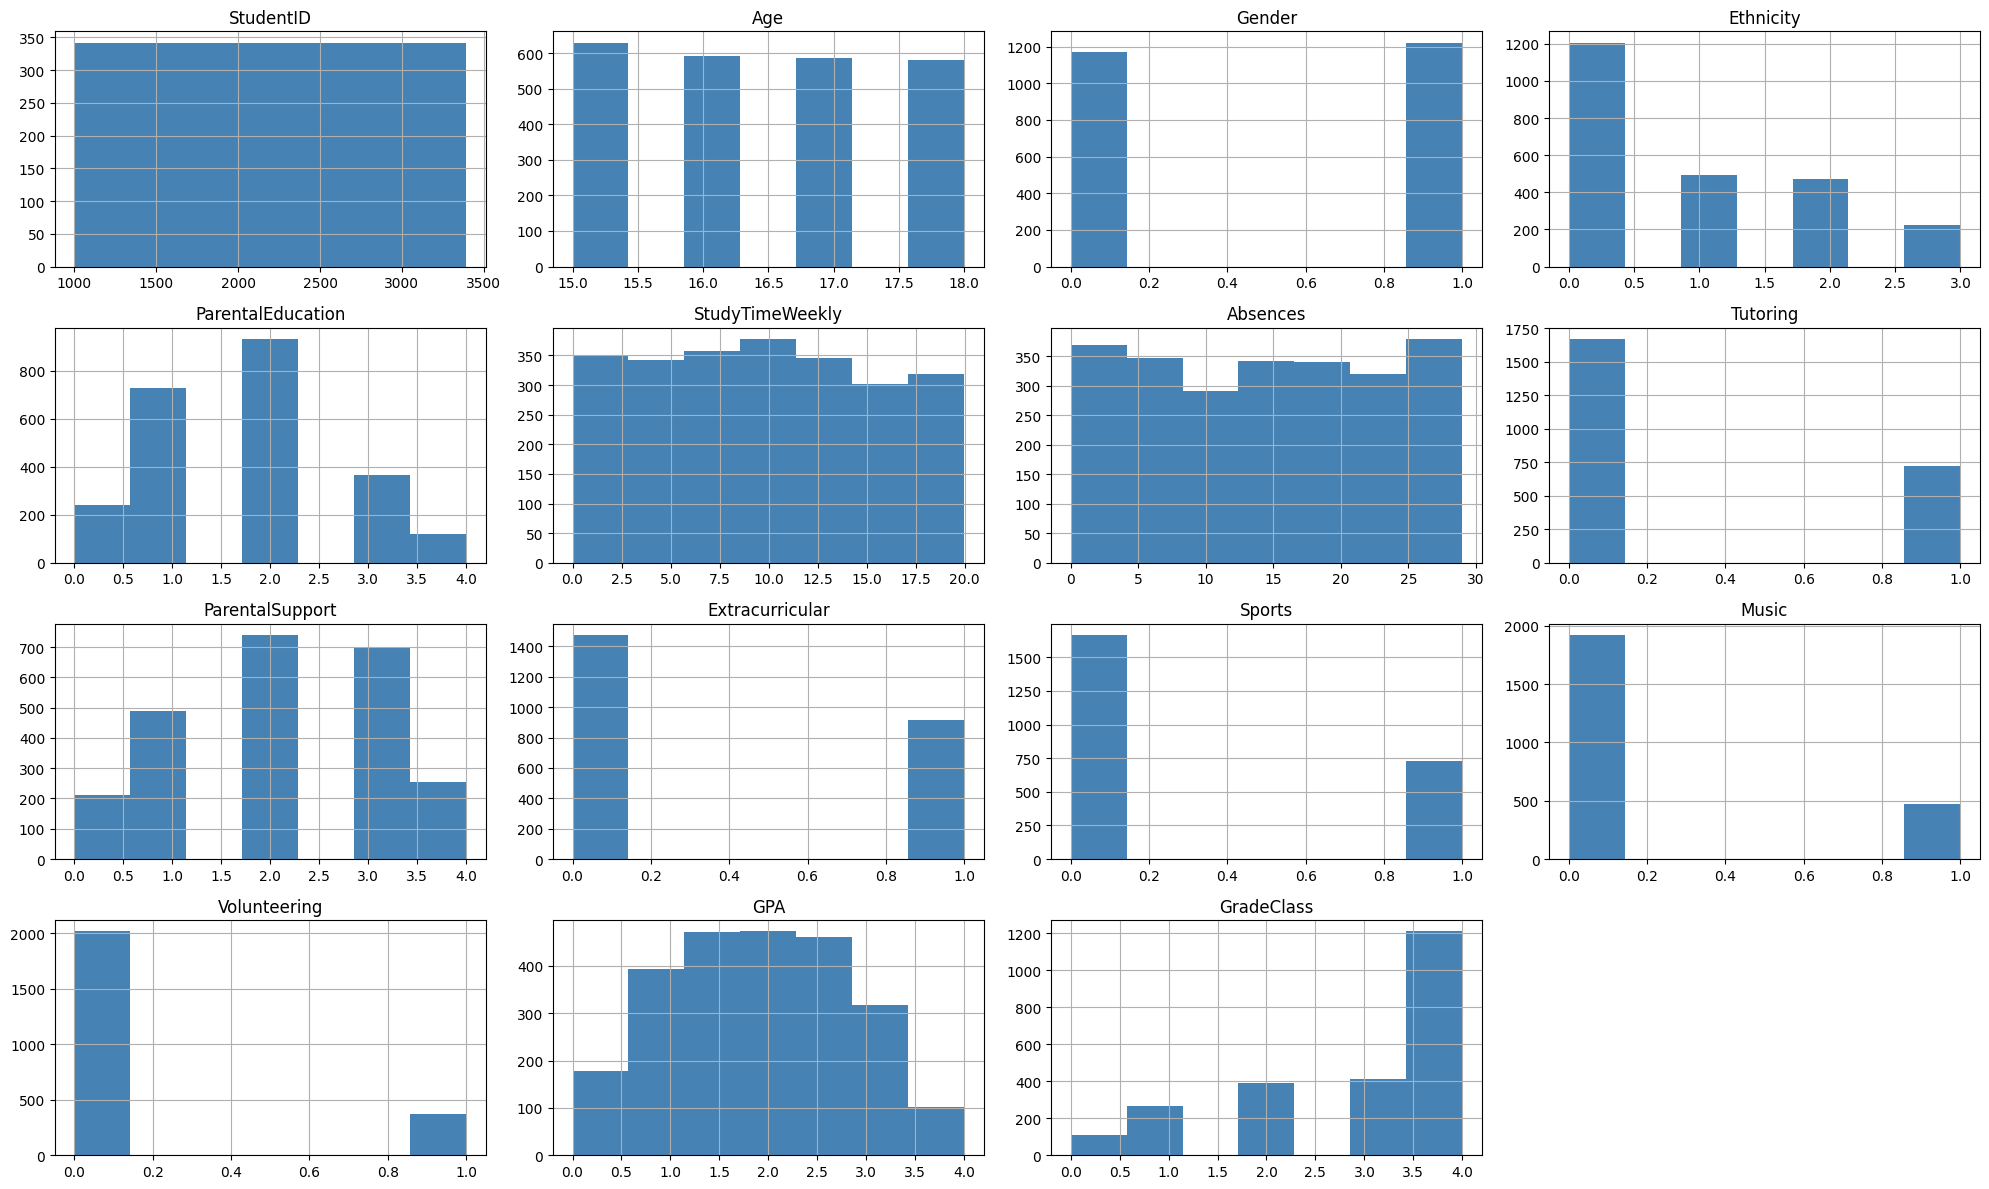

In [4]:

df.hist(figsize=(20, 12), bins=7, color='steelblue')
plt.tight_layout()
plt.show()



**What happened:** Each mini-histogram shows the spread of one column.

Quick takeaways:
- **StudentID** is just a unique ID number per student — evenly spread because it's not a real "feature," just a label.
- **Age** clusters between 15–18, as expected for high schoolers.
- **StudyTimeWeekly** and **Absences** vary quite a bit between students — these look like promising predictors.
- **GradeClass** (our target) has more students in the higher (worse) grade classes than the lowest ones.



---
## 5️⃣ Separating Categorical vs Numerical Features

- A **Categorical** feature has a small number of distinct groups (e.g. Gender: Male/Female).
- A **Numerical** feature can take many different values (e.g. StudyTimeWeekly).

We separate them because we'll treat them differently in the next step: encoding categorical features, and scaling numerical ones.

**How we decide:** if a column has more than 5 unique values, we treat it as numerical; otherwise, categorical.


In [5]:

columns = list(df.columns)

categoric_columns = []
numeric_columns = []

for col in columns:
    if df[col].nunique() > 5:
        numeric_columns.append(col)
    else:
        categoric_columns.append(col)

# StudentID is technically "numeric" by this rule, but it's just an ID, not a real feature — drop it from the list
numeric_columns = numeric_columns[1:]

print("Numerical features:  ", numeric_columns)
print("Categorical features:", categoric_columns)


Numerical features:   ['StudyTimeWeekly', 'Absences', 'GPA']
Categorical features: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GradeClass']



**What happened:** We now have two clean lists. `Age`, `StudyTimeWeekly`, `Absences`, and `GPA` are numerical.
Everything else (Gender, Ethnicity, ParentalEducation, Tutoring, ParentalSupport, Extracurricular, Sports, Music, Volunteering, and our target GradeClass) is categorical.



---
## 6️⃣ Encoding & Scaling — Preparing Data for Machine Learning

Machine learning models only understand **numbers**, and they perform best when numbers are on a **similar scale**. Two steps:

- **Label Encoding**: converts category labels into numbers (already numbers here, but we standardize the process for any dataset).
- **Standard Scaling**: rescales numerical columns so they all have a similar range — this stops one large-scale feature (like Absences, up to 30) from unfairly dominating a smaller-scale one (like Age, around 15-18).


In [6]:

# Make sure numeric columns are stored as decimal numbers (float64)
df[numeric_columns] = df[numeric_columns].astype('float64')

# Encode categorical columns into consistent numeric labels
label_encoder = LabelEncoder()
for column in categoric_columns:
    df[column] = label_encoder.fit_transform(df[column])

# Scale numerical columns so they're all on a comparable range
scaler = StandardScaler()
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

print("Encoding & scaling complete! ✅")
df.head()


Encoding & scaling complete! ✅


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,2,1,0,2,1.780336,-0.890822,1,2,0,0,1,0,1.118086,2
1,1002,3,0,0,1,0.997376,-1.717694,0,1,0,0,0,0,1.242374,1
2,1003,0,0,2,3,-0.984045,1.353542,0,2,0,0,0,0,-1.960277,4
3,1004,2,1,0,3,0.045445,-0.063951,0,3,1,0,0,0,0.161790,3
4,1005,2,1,0,2,-0.902311,0.290422,1,3,0,0,0,0,-0.675573,4



**What happened:** Notice the numerical columns (Age, StudyTimeWeekly, Absences, GPA) now show small values centered around 0 — that's the effect of scaling. The categorical columns were already numeric codes, so they look unchanged, but they're now guaranteed to be in a clean, consistent format for any model.



---
## 7️⃣ Correlation Among Features

**Correlation** measures how strongly two variables move together, from -1 (opposite directions) to +1 (same direction). A heatmap lets us see every pair at once.


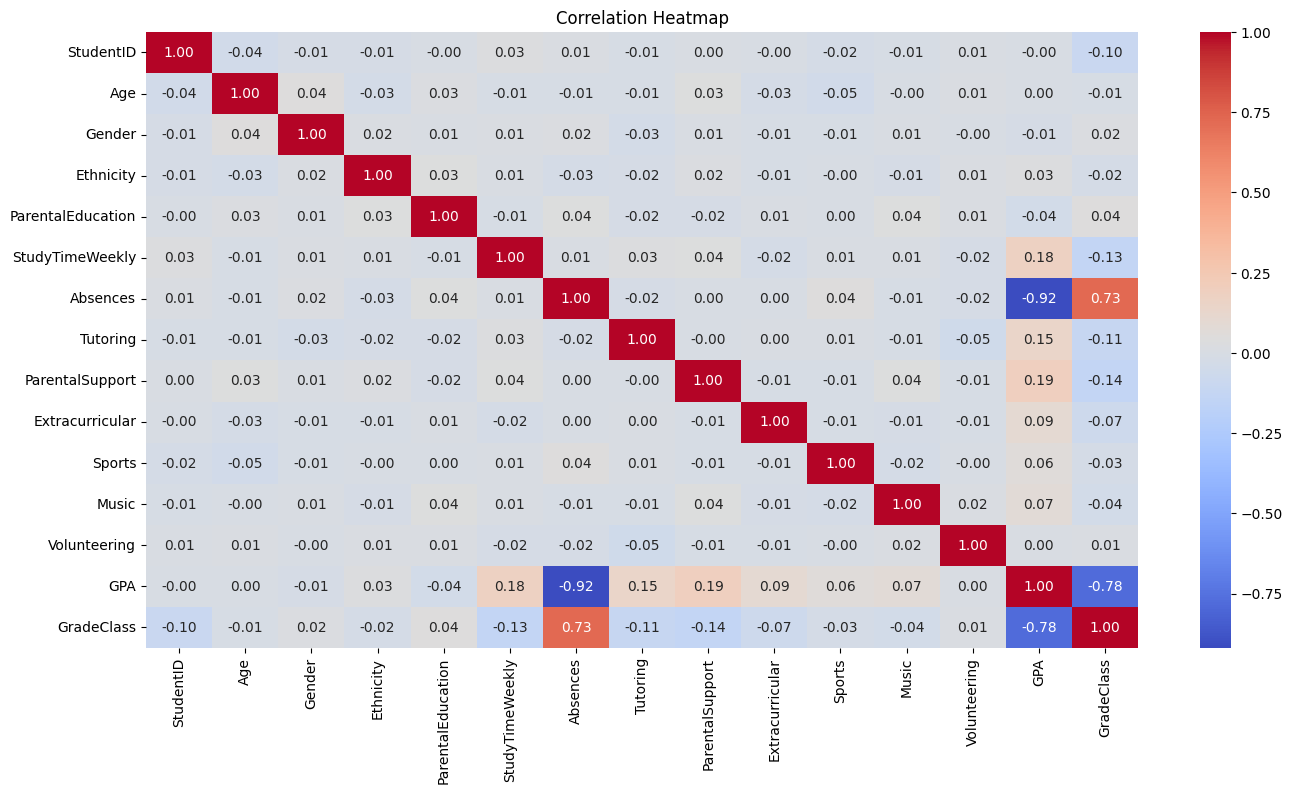

In [7]:

plt.figure(figsize=(16, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()



**What happened:** Look at the **GradeClass** row/column. The strongest correlations with GradeClass are **GPA** (very strong, since GradeClass is literally derived from GPA) and **Absences** (students who miss more classes tend to have a worse GradeClass). This gives us an early hint about which features will matter most for prediction.



---
## 8️⃣ Splitting the Data — Training vs Testing

We split our data into two parts:
- **Training set** (80%): the model learns patterns from this.
- **Testing set** (20%): completely unseen data, used only to check how well the model generalizes.

> 🧠 *This is like studying from practice questions (training) and then being graded on a fresh exam (testing) — you want to know how well you'd do on questions you haven't seen before.*

We drop `GradeClass` (our prediction target), `GPA` (this would be "cheating" since GradeClass is derived directly from GPA), `StudentID` (just an ID, not a real feature), and `Age` (very little variation and weak correlation).


In [8]:

# X = the features we'll use to predict; y = what we're trying to predict
X = df.drop(columns=['GradeClass', 'GPA', 'StudentID', 'Age'])
y = df['GradeClass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)


Training set size: (1913, 11)
Testing set size:  (479, 11)



**What happened:** We now have 1,913 students to train on and 479 held back to test on. `stratify=y` makes sure both sets have a similar mix of each GradeClass, so testing stays fair.



---
## 9️⃣ Which Features Matter Most?

We train a **Random Forest** (a model made of many decision trees) on the full dataset just to ask it one question: *which features did you rely on most to make predictions?*


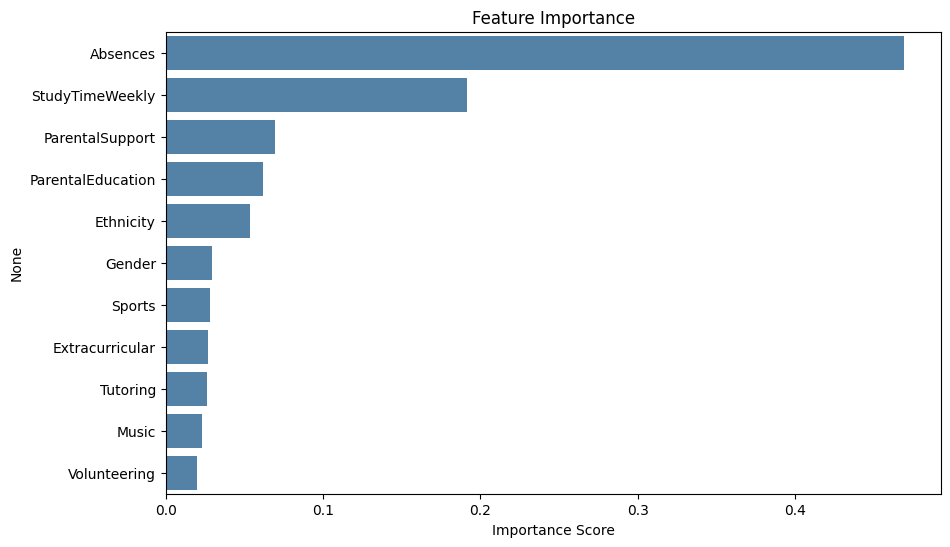

In [9]:

clf = RandomForestClassifier(random_state=42)
clf = clf.fit(X, y)

feature_importance = pd.Series(data=clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(y=feature_importance.index, x=feature_importance.values, color="steelblue")
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()



**What happened:** **Absences** is by far the most important predictor — much more than anything else. **StudyTimeWeekly** and **ParentalSupport** come next, but well behind. This matches the correlation heatmap from earlier and gives a strong, simple takeaway even before we build any prediction model: *going to class matters more than almost anything else here.*



---
## 🔟 Comparing Multiple Prediction Models

There's no single "best" **Algorithm** for every dataset, so we try several and compare their accuracy on the test set — the percentage of students whose GradeClass was correctly predicted.


In [10]:

classification_models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(),
    "CatBoost": CatBoostClassifier(silent=True),
}

model_names = []
accuracies = []

for name, model in classification_models.items():
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    model_names.append(name)
    accuracies.append(score)
    print(f"{name:<25} accuracy: {score:.3f}")

df_models = pd.DataFrame({'Model': model_names, 'Accuracy': accuracies})
fig = px.bar(df_models, x='Model', y='Accuracy', title='Model Accuracies Compared')
fig.show()


Logistic Regression       accuracy: 0.733
K-Nearest Neighbors       accuracy: 0.645
Support Vector Machine    accuracy: 0.745
Decision Tree             accuracy: 0.574


Random Forest             accuracy: 0.697


Gradient Boosting         accuracy: 0.687
AdaBoost                  accuracy: 0.689
Gaussian Naive Bayes      accuracy: 0.678


XGBoost                   accuracy: 0.683


CatBoost                  accuracy: 0.695



**What happened:** Every model was trained on the same 1,913 students and tested on the same unseen 479 students, so the comparison is fair. Most models land somewhere around 65-75% accuracy. The interactive bar chart makes it easy to see which model came out on top — hover over any bar to see its exact score.



---
## 1️⃣1️⃣ Evaluating the Best Model


In [11]:

best_index = accuracies.index(max(accuracies))
best_model_name = model_names[best_index]
best_model = classification_models[best_model_name]

print(f"The best model is: {best_model_name} with an accuracy of {accuracies[best_index]:.3f}")


The best model is: Support Vector Machine with an accuracy of 0.745



**What happened:** We picked whichever model scored highest on the test set, out of the 10 we tried.


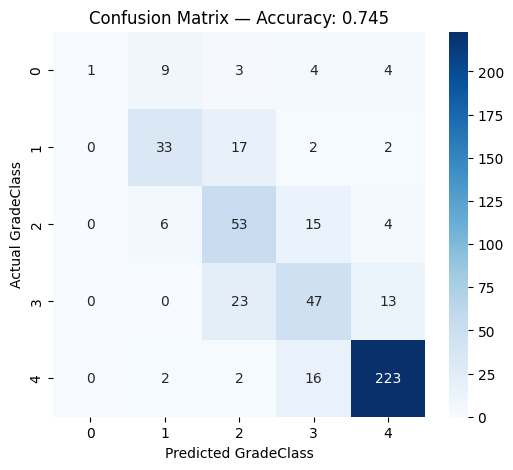

In [12]:

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
score = round(accuracy_score(y_test, y_pred), 3)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues")
plt.xlabel('Predicted GradeClass')
plt.ylabel('Actual GradeClass')
plt.title(f'Confusion Matrix — Accuracy: {score}')
plt.show()



**What is a Confusion Matrix?** It's a grid comparing what the model *predicted* (columns) against what *actually happened* (rows). The diagonal (top-left to bottom-right) shows **correct** predictions — the darker and more concentrated the diagonal, the better the model. Anything off the diagonal is a mistake, and the pattern of mistakes (e.g. mixing up neighboring grade classes 2 and 3) tells us where the model struggles most.



---
## 1️⃣2️⃣ Hyperparameter Tuning

A **hyperparameter** is a setting you choose *before* training (e.g. how strict a model should be). Instead of guessing, we let `GridSearchCV` systematically try many combinations and keep the best one.

We test this on a **Support Vector Machine (SVC)** — testing 5 × 5 = 25 combinations of its two main settings (`C` and `gamma`), each checked with 10-fold cross-validation repeated 3 times for reliability.


In [13]:

model = SVC()

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

search = GridSearchCV(estimator=model, param_grid=grid, cv=cv, scoring='accuracy', n_jobs=-1)
result = search.fit(X_train, y_train)

print('Best cross-validation score: %.3f' % result.best_score_)
print('Best hyperparameters found:', result.best_params_)


Best cross-validation score: 0.752
Best hyperparameters found: {'C': 1000, 'gamma': 0.0001, 'kernel': 'rbf'}



**What happened:** `GridSearchCV` tried every combination of `C` and `gamma` from our grid, each one validated across many train/test splits within the training data (not touching our final test set at all, to keep the comparison fair). It returned the single combination that performed best on average.



---
## 1️⃣3️⃣ Evaluating the Tuned Model

Now let's see how this newly-tuned model performs on our held-out test set.


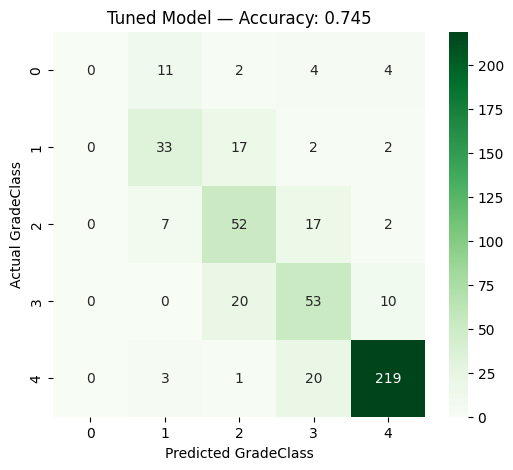

In [14]:

y_pred = result.predict(X_test)
score = round(accuracy_score(y_test, y_pred), 3)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Greens")
plt.xlabel('Predicted GradeClass')
plt.ylabel('Actual GradeClass')
plt.title(f'Tuned Model — Accuracy: {score}')
plt.show()



**What happened:** After tuning, the model's accuracy may go up, stay similar, or occasionally dip slightly compared to the untuned version — hyperparameter tuning helps a model generalize more reliably, but it isn't a guaranteed improvement on every single test set.



---
## 1️⃣4️⃣ Reducing Dimensionality — Using Only the Top 3 Features

**Dimensionality** = the number of features (columns) a model uses. Fewer features means a simpler, faster, easier-to-explain model. Let's see what happens if we throw away everything except the **top 3 most important features** we found earlier: `Absences`, `StudyTimeWeekly`, and `ParentalSupport`.


Using only these features: ['Absences', 'StudyTimeWeekly', 'ParentalSupport']


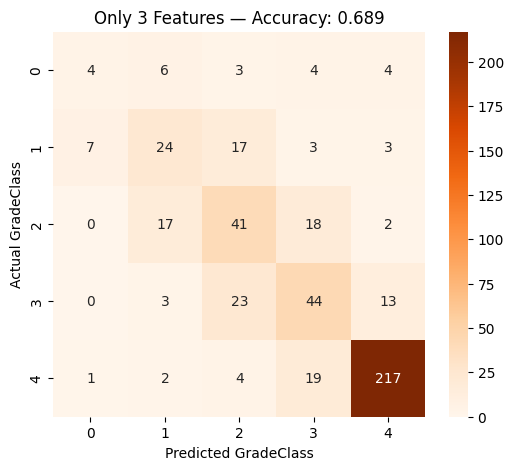

In [15]:

top_features = feature_importance.head(3).index.tolist()
print("Using only these features:", top_features)

X_train_small = X_train[top_features]
X_test_small = X_test[top_features]

model = GradientBoostingClassifier(n_estimators=50, max_depth=5, learning_rate=0.1)
model.fit(X_train_small, y_train)

y_pred = model.predict(X_test_small)
score = round(accuracy_score(y_test, y_pred), 3)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Oranges")
plt.xlabel('Predicted GradeClass')
plt.ylabel('Actual GradeClass')
plt.title(f'Only 3 Features — Accuracy: {score}')
plt.show()



**What happened:** Even using just 3 out of 10 available features, the model still predicts reasonably well — usually only a few percentage points less accurate than using everything. This is a useful trade-off: a small drop in accuracy in exchange for a much simpler, faster, and easier-to-explain model.



---
## 🎯 Conclusion & Key Takeaways

Putting it all together, this project walked through a full beginner machine learning workflow:

✅ Loaded and explored a real 2,392-student dataset
✅ Visualized feature distributions with histograms
✅ Encoded categorical features and scaled numerical ones
✅ Found the strongest correlations with a heatmap
✅ Split data fairly into training and testing sets
✅ Identified **Absences** as the single most important predictor of grades
✅ Compared 10 different prediction models on equal footing
✅ Evaluated the best model with a confusion matrix
✅ Tuned hyperparameters to try to improve it
✅ Simplified the model down to just 3 features with only a small accuracy trade-off

### The big takeaway

The clearest, simplest lesson from all of this analysis:

> **Attendance and study time are the strongest levers a student actually controls.** Parental support matters too, but it's outside a student's control — showing up and studying isn't.

### What to do next
- Try adding your own engineered feature (e.g. a "StudyEfficiency" score combining study time and absences) and see if it improves accuracy.
- Try a different target variable, like predicting `GPA` directly instead of `GradeClass` (this becomes a regression problem instead of classification).
- Revisit `01_Data_Science_Introduction.ipynb`, `02_NumPy.ipynb`, `03_Pandas.ipynb`, and `04_Matplotlib.ipynb` — every core skill used here traces back to something covered in those notebooks.

**You don't need any other file to understand this notebook — every import, step, and result was explained above.**



---
## 📖 Mini Glossary — Machine Learning Terms Used Here

| Term | Simple Definition |
|---|---|
| Algorithm | A step-by-step strategy a model uses to learn patterns |
| Categorical Feature | A column with a small number of distinct groups |
| Confusion Matrix | A grid comparing predicted vs actual outcomes |
| Correlation | How strongly two variables move together |
| Cross-Validation | Testing a model on several different train/test splits for reliability |
| Encoding | Converting category labels into numbers a model can use |
| Feature Importance | A score showing how much a model relied on each feature |
| Hyperparameter | A setting chosen before training (not learned from data) |
| Numerical Feature | A column that can take many different values |
| Scaling | Rescaling numbers so features are on a comparable range |
| Test Set | Unseen data used only to check how well a model generalizes |
| Train/Test Split | Dividing data into a portion to learn from and a portion to test on |
| Training Set | The data a model actually learns patterns from |
